# New York City Airbnb Regression Analysis

*Adapted from material originally developed for CPSC 330 (Applied Machine Learning) at the University of British Columbia.*

## Table of contents
1. [Problem Definition](#1)
2. [Data Splitting](#2)
3. [Exploratory Data Analysis](#3)
4. [Feature Engineering](#4)
5. [Preprocessing and Transformations](#5) 
6. [Baseline Model](#6)
7. [Linear Models](#7)
8. [Model Comparison](#8)
9. [Feature Selection](#9)
10. [Hyperparameter Optimization](#10)
11. [Model Interpretation and Feature Importances](#11) 
12. [Final Evaluation on the test set](#12)
13. [Summary of the results](#13)
14. [Key takeaways](#14)
15. [Limitations and Future Improvements](#15)

## Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate, train_test_split
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error
import shap

<br><br>

## 1. Problem Definition <a id="1"></a>
<hr>

This project explores a regression problem using a dataset of New York City Airbnb listings from 2019. The goal is to predict `reviews_per_month`, representing the average number of monthly reviews a listing receives, as a proxy for listing popularity.

The dataset contains detailed information about Airbnb listings, including location, accommodation type, pricing, and availability. It contains 48,895 observations and 15 features per listing.

Predicting listing popularity could be useful for understanding which characteristics are associated with higher engagement and how different listing attributes may influence demand. While `reviews_per_month` serves as the target variable in this analysis, other measures such as vacancy rate or average rating could also be used in a real-world setting.

In [2]:
nyc_df = pd.read_csv("data/NYC_data.csv", index_col=0)
nyc_df.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
nyc_df.shape

(48895, 15)

<br><br>

## 2. Data Splitting <a id="2"></a>
<hr>

The dataset was split into training (70%) and test (30%) portions using `random_state=123`.

In [4]:
train_df, test_df = train_test_split(nyc_df, test_size=0.30, random_state=123)
train_df.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
id,,,,,,,,,,,,,,,
28736148,Cozy 1 Bedroom Apt in Hamilton Heights,43431867,Tommy,Manhattan,Washington Heights,40.83256,-73.94440,Entire home/apt,96,4,0,NaN,NaN,1,17
34613254,Amazing One Bedroom at the Time Square Area/72B,48146336,Irina,Manhattan,Hell's Kitchen,40.76134,-73.99299,Entire home/apt,150,30,0,NaN,NaN,20,332
11144496,"New Spacious Master, Williamsburg",48819868,Nick,Brooklyn,Williamsburg,40.71119,-73.95097,Private room,200,1,0,NaN,NaN,1,0
766814,Adorable Midtown West Studio!,4022922,Caitlin,Manhattan,Hell's Kitchen,40.75900,-73.99530,Entire home/apt,95,1,0,NaN,NaN,1,0
16162621,NEW! Exceptional 2BR/1BA Williamsburg Oasis,104781467,Russell,Brooklyn,Williamsburg,40.71306,-73.94856,Entire home/apt,199,3,1,2016-12-11,0.03,1,0


<br><br>

## 3. Exploratory Data Analysis <a id="3"></a>
<hr>

The first step in the EDA is to examine the summary statistics and structure of the training dataset. This provides an overview of the distribution, key statistics and range of each feature, while also helping identify variable types, missing values, and potential scaling issues that may need to be addressed before modeling.

In [5]:
train_df.describe(include='all')

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,34216,3.422600e+04,34209,34226,34226,34226.000000,34226.000000,34226,34226.000000,34226.000000,34226.000000,27236,27236.000000,34226.000000,34226.000000
unique,33662,NaN,9201,5,218,NaN,NaN,3,NaN,NaN,NaN,1676,NaN,NaN,NaN
top,Home away from home,NaN,David,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,14,NaN,292,15176,2728,NaN,NaN,17848,NaN,NaN,NaN,984,NaN,NaN,NaN
mean,NaN,6.726273e+07,NaN,NaN,NaN,40.729142,-73.952083,NaN,151.528399,7.094957,23.244814,NaN,1.369816,7.042453,112.526004
std,NaN,7.840511e+07,NaN,NaN,NaN,0.054531,0.046201,NaN,236.628392,21.548290,44.573323,NaN,1.700737,32.590803,131.420031
min,NaN,2.438000e+03,NaN,NaN,NaN,40.506410,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,NaN,7.721897e+06,NaN,NaN,NaN,40.690193,-73.983030,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,NaN,3.074526e+07,NaN,NaN,NaN,40.723240,-73.955550,NaN,106.000000,3.000000,5.000000,NaN,0.710000,1.000000,45.000000
75%,NaN,1.068375e+08,NaN,NaN,NaN,40.763287,-73.936270,NaN,175.000000,5.000000,23.000000,NaN,2.000000,2.000000,225.750000


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 34226 entries, 28736148 to 12711351
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            34216 non-null  str    
 1   host_id                         34226 non-null  int64  
 2   host_name                       34209 non-null  str    
 3   neighbourhood_group             34226 non-null  str    
 4   neighbourhood                   34226 non-null  str    
 5   latitude                        34226 non-null  float64
 6   longitude                       34226 non-null  float64
 7   room_type                       34226 non-null  str    
 8   price                           34226 non-null  int64  
 9   minimum_nights                  34226 non-null  int64  
 10  number_of_reviews               34226 non-null  int64  
 11  last_review                     27236 non-null  str    
 12  reviews_per_month               27236 

In [7]:
train_df["neighbourhood"].value_counts()

neighbourhood
Williamsburg          2728
Bedford-Stuyvesant    2593
Harlem                1874
Bushwick              1723
Upper West Side       1410
                      ... 
Co-op City               1
Sea Gate                 1
Neponsit                 1
Eltingville              1
Woodrow                  1
Name: count, Length: 218, dtype: int64

<br>

I wanted to further investigate the categorical variable `neighbourhood`, as it showed high cardinality in the dataset.

<br>
<hr>

<br>

The first visualization examines the geographical distribution of Airbnb listings across New York City. This provides insight into where lower and higher-priced listings are concentrated across the city. To improve readability and highlight the denser areas of the map, an upper threshold based on the mean nightly price is applied.

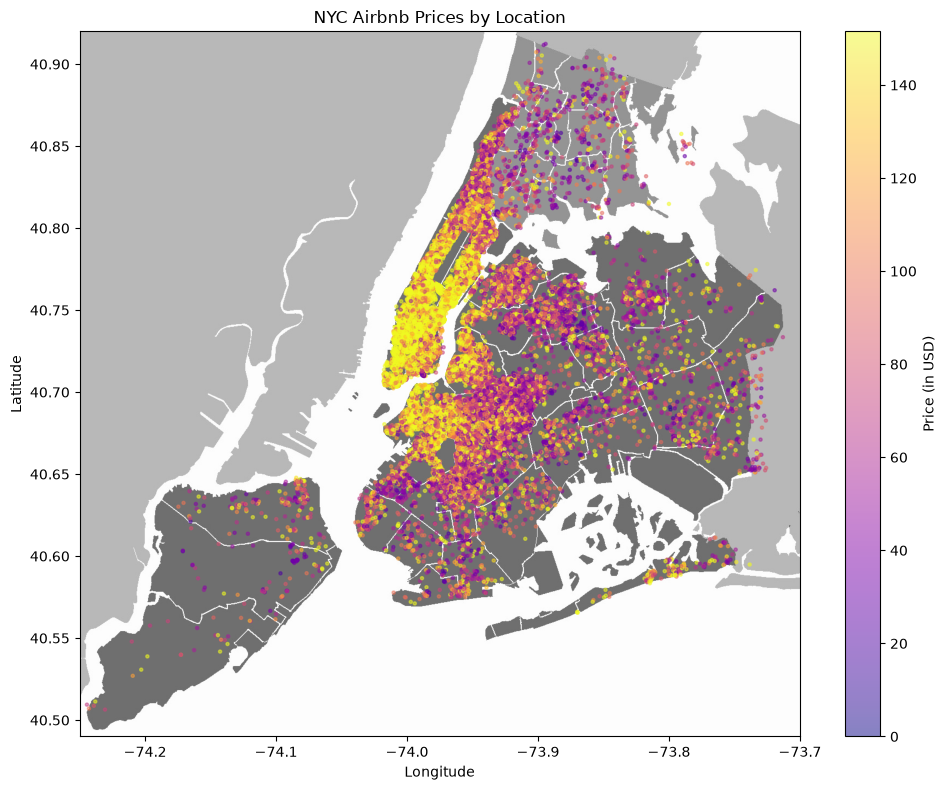

In [8]:
plt.figure(figsize=(10, 8))
image = mpimg.imread("data/NYC_Image.jpg")  
extent = [-74.25, -73.7, 40.49, 40.92]  
plt.imshow(image, extent=extent, aspect='auto', zorder=0)

plt.scatter(train_df['longitude'], train_df['latitude'], c=train_df['price'].clip(upper=train_df['price'].mean()),
            cmap='plasma', s=5, alpha=0.5, zorder=1)

plt.colorbar(label="Price (in USD)")
plt.title("NYC Airbnb Prices by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

<br>

This next visualization shows the number of Airbnb listings in each neighbourhood group, allowing us to identify the areas of New York City with the highest concentration of listings.

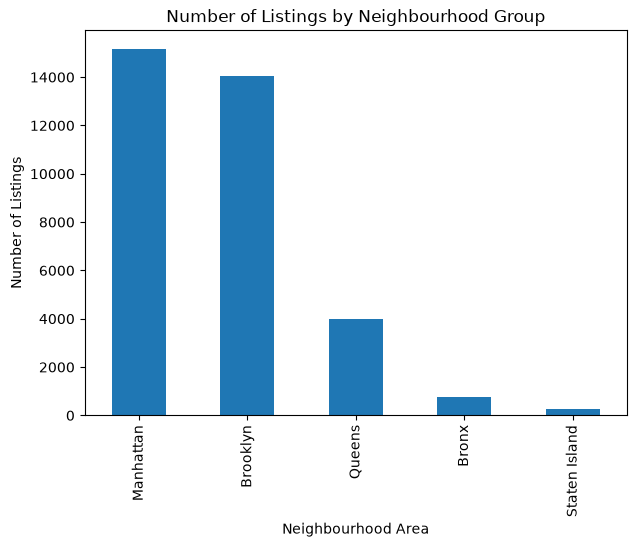

In [9]:
plt.figure(figsize=(7, 5))
train_df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Area")
plt.ylabel("Number of Listings")
plt.show()

<br>

The final visualization examines the relationship between nightly price and reviews per month using a simple scatterplot. To improve readability, the visualization is limited to listings with up to 25 reviews per month and a nightly price of up to $1,000. This helps make the overall patterns and relationships between price and review frequency easier to observe.

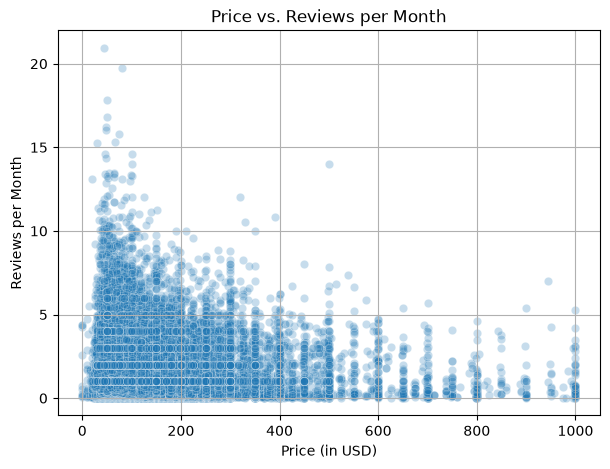

In [10]:
nyc_df_scatter = nyc_df[(nyc_df['reviews_per_month'] <= 25) & (nyc_df['price'] <= 1000)]

plt.figure(figsize=(7, 5))
sns.scatterplot(x='price', y='reviews_per_month', data=nyc_df_scatter, alpha=0.25)
plt.title("Price vs. Reviews per Month")
plt.xlabel("Price (in USD)")
plt.ylabel("Reviews per Month")
plt.grid(True)
plt.show()

### Initial observations about the data

- The initial EDA highlighted the need for several preprocessing steps, including imputing missing values, applying one-hot encoding to categorical features, and scaling numerical variables. The visualizations also revealed that Manhattan tends to have the highest concentration of listings and the most expensive Airbnb prices. Finally, the scatterplot of price and reviews per month suggested an inverse relationship, with the number of monthly reviews tending to decrease as price increases, potentially following an exponential pattern. All analyses were conducted exclusively on the training set to prevent data leakage from the test set.

- For this analysis, I will use the $R^2$ and RMSE (Root Mean Squared Error) as the evaluation metrics to assess the performance of the predictions.

<br><br>

## 4. Feature Engineering <a id="4"></a>
<hr>

I decided to introduce two new features. The first is the numerical feature `total_price`, calculated as the cost of a night in the Airbnb multiplied by `minimum_nights`. The second is the binary feature `is_manhattan`, which indicates whether the Airbnb is located in Manhattan.

In [11]:
train_df['total_price'] = train_df['price'] * train_df['minimum_nights']
test_df['total_price'] = test_df['price'] * test_df['minimum_nights']

train_df['is_manhattan'] = train_df['neighbourhood_group'] == 'Manhattan'
test_df['is_manhattan'] = test_df['neighbourhood_group'] == 'Manhattan'

train_df.head()

,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,total_price,is_manhattan
id,,,,,,,,,,,,,,,,,
28736148,Cozy 1 Bedroom Apt in Hamilton Heights,43431867,Tommy,Manhattan,Washington Heights,40.83256,-73.94440,Entire home/apt,96,4,0,NaN,NaN,1,17,384,True
34613254,Amazing One Bedroom at the Time Square Area/72B,48146336,Irina,Manhattan,Hell's Kitchen,40.76134,-73.99299,Entire home/apt,150,30,0,NaN,NaN,20,332,4500,True
11144496,"New Spacious Master, Williamsburg",48819868,Nick,Brooklyn,Williamsburg,40.71119,-73.95097,Private room,200,1,0,NaN,NaN,1,0,200,False
766814,Adorable Midtown West Studio!,4022922,Caitlin,Manhattan,Hell's Kitchen,40.75900,-73.99530,Entire home/apt,95,1,0,NaN,NaN,1,0,95,True
16162621,NEW! Exceptional 2BR/1BA Williamsburg Oasis,104781467,Russell,Brooklyn,Williamsburg,40.71306,-73.94856,Entire home/apt,199,3,1,2016-12-11,0.03,1,0,597,False


<br><br>

## 5. Preprocessing and Transformations <a id="5"></a>
<hr>

The features `id`, `name`, `host_id`, `host_name` and `last_review` are going to be removed from the analysis, since most of these features provide listing-specific information that is unlikely to offer meaningful predictive value. Although `last_review` could be transformed into a numerical feature representing the number of days since the most recent review relative to a fixed date, this would introduce a highly specific and somewhat arbitrary reference point. The `neighbourhood` feature was also dropped due to its high cardinality of 218 unique values, as encoding such a large number of categories would add considerable complexity to the model.

In [12]:
numeric_feats = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 
                 'calculated_host_listings_count', 'availability_365', 'total_price'] 
categorical_feats = ['neighbourhood_group', 'room_type'] 
binary_feats = ['is_manhattan'] 
drop_feats = ['name', 'host_id', 'host_name', 'last_review', 'neighbourhood']

In [13]:
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_feats),
    (OneHotEncoder(drop="if_binary"), binary_feats),
    (OneHotEncoder(handle_unknown="ignore"), categorical_feats),    
    ("drop", drop_feats)    
)

<br>

Additionally, rows with missing values in the target variable `reviews_per_month` were also removed from the analysis, as these observations cannot be used for supervised regression.

In [14]:
train_df = train_df.dropna(subset=['reviews_per_month'])
test_df = test_df.dropna(subset=['reviews_per_month'])

In [15]:
X_train = train_df.drop(columns=['reviews_per_month'])
y_train = train_df['reviews_per_month']
X_test = test_df.drop(columns=['reviews_per_month'])
y_test = test_df['reviews_per_month']

<br><br>

## 6. Baseline Model <a id="6"></a>
<hr>

First, a baseline model from `scikit-learn` is used to establish a reference point for evaluating subsequent models.

In [16]:
dummy = DummyRegressor(strategy="mean")

In [17]:
dummy.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[1.37]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](16,)","['name','host_id','host_name',...,'availability_365','total_price', 'is_manhattan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,16
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [18]:
dummy.predict(X_train)

array([1.36981642, 1.36981642, 1.36981642, ..., 1.36981642, 1.36981642,
       1.36981642], shape=(27236,))

In [19]:
pd.DataFrame(cross_validate(dummy, X_train, y_train, cv=10, return_train_score=True)).mean()

fit_time       0.002814
score_time     0.000391
test_score    -0.000499
train_score    0.000000
dtype: float64

### Results

The dummy regressor, used as the baseline model, predicted the mean value of `reviews_per_month` (1.3698) for all instances. After performing cross-validation, it achieved a mean training $R^2$ of 0 and a mean validation $R^2$ of -0.0005. This confirms that the model has essentially no predictive power and serves only as a reference point for evaluating improvements from more complex models.

<br><br>

## 7. Linear Models <a id="7"></a>
<hr>


The next step is to evaluate a linear model as the first substantive approach, tune its complexity hyperparameter to explore different model configurations and report the resulting cross-validation scores together with their standard deviations.

In [20]:
lr = make_pipeline(preprocessor, Ridge())
lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['name','host_id','host_name',...,'availability_365','total_price', 'is_manhattan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder-1', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automat

In [21]:
pd.DataFrame(cross_validate(lr, X_train, y_train, cv=10, return_train_score=True)).mean()

fit_time       0.031208
score_time     0.005909
test_score     0.334866
train_score    0.333747
dtype: float64

In [22]:
param_grid = {"ridge__alpha": 10.0 ** np.arange(-5, 5, 1)}

pipe_ridge = make_pipeline(preprocessor, Ridge())

grid_search = GridSearchCV(pipe_ridge, param_grid, return_train_score=True, n_jobs=-1)

grid_search.fit(X_train, y_train)

train_scores = grid_search.cv_results_["mean_train_score"]
cv_scores = grid_search.cv_results_["mean_test_score"]

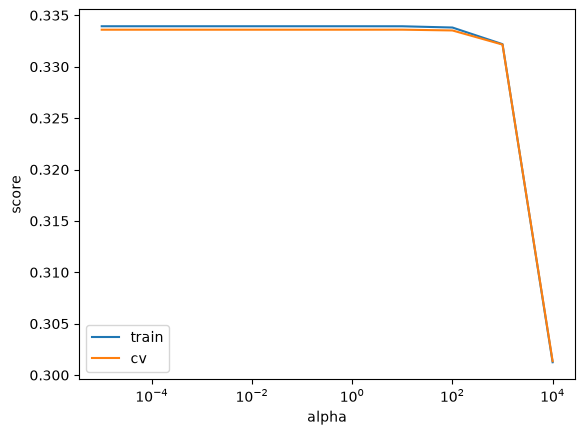

In [23]:
train_scores = grid_search.cv_results_['mean_train_score']
cv_scores = grid_search.cv_results_['mean_test_score']

plt.semilogx(param_grid['ridge__alpha'], train_scores.tolist(), label='train')
plt.semilogx(param_grid['ridge__alpha'], cv_scores.tolist(), label='cv')
plt.legend()
plt.xlabel('alpha')
plt.ylabel('score');

In [24]:
best_alpha = grid_search.best_params_['ridge__alpha']
print(f"Best alpha: {best_alpha}")

results = pd.DataFrame(grid_search.cv_results_)

results[['params', 'mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']]

Best alpha: 10.0


,params,mean_train_score,std_train_score,mean_test_score,std_test_score
0,{'ridge__alpha': 1e-05},0.333937,0.008432,0.333601,0.029796
1,{'ridge__alpha': 0.0001},0.333937,0.008432,0.333601,0.029796
2,{'ridge__alpha': 0.001},0.333937,0.008432,0.333601,0.029796
3,{'ridge__alpha': 0.01},0.333937,0.008432,0.333601,0.029796
4,{'ridge__alpha': 0.1},0.333937,0.008432,0.333601,0.029796
5,{'ridge__alpha': 1.0},0.333937,0.008432,0.333602,0.029798
6,{'ridge__alpha': 10.0},0.333935,0.008433,0.333604,0.029812
7,{'ridge__alpha': 100.0},0.333813,0.008440,0.333528,0.029890
8,{'ridge__alpha': 1000.0},0.332194,0.008450,0.332153,0.029839
9,{'ridge__alpha': 10000.0},0.301249,0.007643,0.301356,0.026915


### Results

As the first linear model, Ridge regression achieved a training $R^2$ of 0.333747 and a validation $R^2$ of 0.334866 after cross-validation. A Grid Search over the regularization parameter alpha found `alpha=10`to be the best configuration, resulting in a training $R^2$ of 0.333935 and a validation $R^2$ of 0.333604. Overall, this indicates that Ridge regression captured meaningful patterns in the data and provided a substantial improvement over the baseline model. However, the small difference between the default and optimized $R^2$ values suggests that tuning alpha had minimal impact. In both cases, the validation $R^2$ remained around 0.33, indicating moderate predictive performance.

<br><br>

## 8. Model Comparison <a id="8"></a>
<hr>

The linear model from the previous section is now compared with three additional regression models: a decision tree, k-nearest neighbours and a random forest. Their training and validation performance is then examined to assess how well each model generalizes and to identify potential overfitting or underfitting.

In [25]:
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    
    """
    Parameters
    ----------
    model :
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [26]:
results_dict = {} 

models = {
    "dummy": DummyRegressor(strategy="mean"),
    "ridge": Ridge(),  
    "decision tree": DecisionTreeRegressor(random_state=123),
    "kNN": KNeighborsRegressor(),
    "random forest":RandomForestRegressor(random_state=123),
}

In [27]:
for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    results_dict[name] = mean_std_cross_val_scores(
        pipe, X_train, y_train, cv=5, return_train_score=True
    )
    

diff_models_df = pd.DataFrame(results_dict).T 

In [28]:
diff_models_df

,fit_time,score_time,test_score,train_score
dummy,0.020 (+/- 0.003),0.005 (+/- 0.000),-0.000 (+/- 0.000),0.000 (+/- 0.000)
ridge,0.023 (+/- 0.004),0.007 (+/- 0.003),0.334 (+/- 0.033),0.334 (+/- 0.009)
decision tree,0.147 (+/- 0.005),0.008 (+/- 0.001),-0.118 (+/- 0.199),1.000 (+/- 0.000)
kNN,0.025 (+/- 0.009),0.350 (+/- 0.111),0.385 (+/- 0.022),0.594 (+/- 0.009)
random forest,7.903 (+/- 0.213),0.133 (+/- 0.030),0.526 (+/- 0.031),0.933 (+/- 0.001)


### Results

The Decision Tree model showed severe overfitting, with a perfect training $R^2$ of 1.000 and a negative validation score, indicating poor generalization. The kNN model performed better, achieving a training $R^2$ of 0.594 and a validation $R^2$ of 0.385, slightly outperforming Ridge regression. The Random Forest model achieved a high training $R^2$ of 0.933 and the best validation score at $R^2$ = 0.528, although the gap between the two scores suggests some overfitting. In terms of fit and score times, kNN was the fastest, while Random Forest was more computationally expensive. Overall, both kNN and Random Forest outperformed the linear Ridge regression model.

<br><br>

## 9. Feature Selection <a id="9"></a>
<hr>

In this section, `RFECV` (Recursive Feature Elimination with Cross-Validation) is used to identify the most relevant features for the regression models.

In [29]:
estimator = Ridge(alpha=best_alpha)  

rfe_cv = RFECV(estimator=estimator, step=1, cv=10, scoring='r2' , n_jobs=-1)

In [30]:
X_train_scaled = preprocessor.fit_transform(X_train)
rfe_cv.fit(X_train_scaled, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,Ridge(alpha=np.float64(10.0))
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",10
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'r2'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at each step. .. versionadded:: 1.5split(k)_ranking

In [31]:
print(rfe_cv.support_)
print(train_df.columns[rfe_cv.support_])

[ True  True False  True  True  True  True False  True  True  True  True
  True  True  True False  True]
Index(['name', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'is_manhattan'],
      dtype='str')


In [32]:
results_dict_rfecv = {}

for name, model in models.items():
    rfe_pipe = make_pipeline(preprocessor, rfe_cv, model)
    results_dict_rfecv[name] = mean_std_cross_val_scores(
        rfe_pipe, X_train, y_train, cv=5, return_train_score=True
    )

In [33]:
diff_models_df

,fit_time,score_time,test_score,train_score
dummy,0.020 (+/- 0.003),0.005 (+/- 0.000),-0.000 (+/- 0.000),0.000 (+/- 0.000)
ridge,0.023 (+/- 0.004),0.007 (+/- 0.003),0.334 (+/- 0.033),0.334 (+/- 0.009)
decision tree,0.147 (+/- 0.005),0.008 (+/- 0.001),-0.118 (+/- 0.199),1.000 (+/- 0.000)
kNN,0.025 (+/- 0.009),0.350 (+/- 0.111),0.385 (+/- 0.022),0.594 (+/- 0.009)
random forest,7.903 (+/- 0.213),0.133 (+/- 0.030),0.526 (+/- 0.031),0.933 (+/- 0.001)


In [34]:
rfe_models_df = pd.DataFrame(results_dict_rfecv).T 
rfe_models_df

,fit_time,score_time,test_score,train_score
dummy,0.274 (+/- 0.016),0.008 (+/- 0.001),-0.000 (+/- 0.000),0.000 (+/- 0.000)
ridge,0.264 (+/- 0.008),0.008 (+/- 0.000),0.334 (+/- 0.033),0.334 (+/- 0.009)
decision tree,0.357 (+/- 0.007),0.008 (+/- 0.001),-0.053 (+/- 0.240),1.000 (+/- 0.000)
kNN,0.292 (+/- 0.014),0.215 (+/- 0.025),0.400 (+/- 0.025),0.598 (+/- 0.010)
random forest,6.005 (+/- 0.092),0.126 (+/- 0.012),0.522 (+/- 0.034),0.932 (+/- 0.001)


### Results

Feature selection using `RFECV` did not lead to meaningful improvements in validation performance. In fact, the Random Forest validation $R^2$ slightly decreased from 0.528 to 0.522. Therefore, `RFECV` was not included in the final pipeline.

<br><br>

## 10. Hyperparameter Optimization <a id="10"></a>
<hr>

Next, we look to optimize the hyperparameters using Grid Search. For the Random Forest model, multiple hyperparameters are tuned simultaneously to identify the best-performing configuration.

In [35]:
# Decision Tree

tree_pipe = make_pipeline(preprocessor, DecisionTreeRegressor(random_state=123))
param_grid_tree = {'decisiontreeregressor__max_depth': range(1, 20)}
grid_tree = GridSearchCV(tree_pipe, param_grid_tree, cv=5, scoring='r2')
grid_tree.fit(X_train, y_train)
print("Best Decision Tree depth:", grid_tree.best_params_)

Best Decision Tree depth: {'decisiontreeregressor__max_depth': 6}


In [36]:
# kNN

knn_pipe = make_pipeline(preprocessor, KNeighborsRegressor())
param_grid_knn = {'kneighborsregressor__n_neighbors': range(1, 30)}
grid_knn = GridSearchCV(knn_pipe, param_grid_knn, cv=5, scoring='r2')
grid_knn.fit(X_train, y_train)
print("Best k for kNN:", grid_knn.best_params_)

Best k for kNN: {'kneighborsregressor__n_neighbors': 15}


In [37]:
# Random Forest

rf_pipe = make_pipeline(preprocessor, RandomForestRegressor(random_state=123))

param_dist_rf = {
    'randomforestregressor__n_estimators': [50, 100, 150, 200],
    'randomforestregressor__max_depth': [None, 10, 20, 30],
    'randomforestregressor__max_features': [None, 'sqrt', 'log2'],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

random_rf = RandomizedSearchCV(rf_pipe, param_distributions=param_dist_rf, n_iter=15, cv=5, 
                               scoring='r2', n_jobs = -1, random_state=123)

random_rf.fit(X_train, y_train)
print("Best RF params:", random_rf.best_params_)

Best RF params: {'randomforestregressor__n_estimators': 100, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__max_features': 'log2', 'randomforestregressor__max_depth': 20}


In [38]:
best_dt = DecisionTreeRegressor(max_depth=6, random_state=123)
best_knn = KNeighborsRegressor(n_neighbors=17)
best_rf =  RandomForestRegressor(n_estimators=100, max_depth=20, max_features='log2', min_samples_split=5, random_state=123)

models_optimized = {
    "decision tree": best_dt,
    "kNN": best_knn,
    "random forest": best_rf,
}

In [39]:
results_dict_optimized = {}

for name, model in models_optimized.items():
    optimized_pipe = make_pipeline(preprocessor, model)
    results_dict_optimized[name] = mean_std_cross_val_scores(
        optimized_pipe, X_train, y_train, cv=5, return_train_score=True
    )

In [40]:
diff_models_df

,fit_time,score_time,test_score,train_score
dummy,0.020 (+/- 0.003),0.005 (+/- 0.000),-0.000 (+/- 0.000),0.000 (+/- 0.000)
ridge,0.023 (+/- 0.004),0.007 (+/- 0.003),0.334 (+/- 0.033),0.334 (+/- 0.009)
decision tree,0.147 (+/- 0.005),0.008 (+/- 0.001),-0.118 (+/- 0.199),1.000 (+/- 0.000)
kNN,0.025 (+/- 0.009),0.350 (+/- 0.111),0.385 (+/- 0.022),0.594 (+/- 0.009)
random forest,7.903 (+/- 0.213),0.133 (+/- 0.030),0.526 (+/- 0.031),0.933 (+/- 0.001)


In [41]:
optimized_models_df = pd.DataFrame(results_dict_optimized).T 
optimized_models_df

,fit_time,score_time,test_score,train_score
decision tree,0.093 (+/- 0.037),0.007 (+/- 0.000),0.467 (+/- 0.034),0.521 (+/- 0.019)
kNN,0.045 (+/- 0.013),0.463 (+/- 0.115),0.424 (+/- 0.036),0.487 (+/- 0.010)
random forest,2.355 (+/- 0.224),0.094 (+/- 0.002),0.546 (+/- 0.035),0.856 (+/- 0.005)


### Results

Even though all three models had a decrease in their training scores, this was compensated by better generalization on the test set. We can now see that the training and testing scores are much closer, indicating that the models are learning better rather than overfitting to the training set. All three models showed an increase in their test scores, most notably the Decision Tree, which improved from a negative score to close to 0.5.

<br><br>

## 11. Model Interpretation and Feature Importances <a id="11"></a>
<hr>

`SHAP` will now be used to examine the importance of the features in one of the non-linear models.

In [42]:
rf_model = random_rf.best_estimator_
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['name','host_id','host_name',...,'availability_365','total_price', 'is_manhattan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder-1', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit`

In [43]:
feature_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(
    data=preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index,
)

X_train_enc.head()

,standardscaler__latitude,standardscaler__longitude,standardscaler__price,standardscaler__minimum_nights,standardscaler__number_of_reviews,standardscaler__calculated_host_listings_count,standardscaler__availability_365,standardscaler__total_price,onehotencoder-1__is_manhattan_True,onehotencoder-2__neighbourhood_group_Bronx,onehotencoder-2__neighbourhood_group_Brooklyn,onehotencoder-2__neighbourhood_group_Manhattan,onehotencoder-2__neighbourhood_group_Queens,onehotencoder-2__neighbourhood_group_Staten Island,onehotencoder-2__room_type_Entire home/apt,onehotencoder-2__room_type_Private room,onehotencoder-2__room_type_Shared room
id,,,,,,,,,,,,,,,,,
16162621,-0.275211,0.054428,0.312196,-0.155184,-0.585393,-0.157730,-0.886370,-0.042978,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
14807279,-0.765704,-0.174210,0.452339,-0.103186,1.717955,-0.157730,0.164338,-0.001363,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
27573483,-0.606211,-0.450669,0.317587,0.052807,-0.585393,-0.081152,0.372934,0.067309,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
19154733,-0.266107,0.157753,0.452339,-0.103186,-0.460887,-0.119441,-0.824563,-0.001363,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
28736839,1.516710,-0.006201,0.856598,-0.259180,-0.585393,-0.157730,-0.886370,-0.083769,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [44]:
model = rf_pipe.named_steps["randomforestregressor"]
model.fit(X_train_enc, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",123
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease 

In [45]:
explainer = shap.TreeExplainer(model, feature_perturbation="auto", model_output="raw", approximate=True)

Since computing SHAP values on the full training set can be very time-consuming, I will use a random subset to make the process faster while still allowing us to interpret the model's behavior.

In [46]:
sample = X_train_enc.sample(150, random_state=123)  
train_shap_values = explainer(sample)

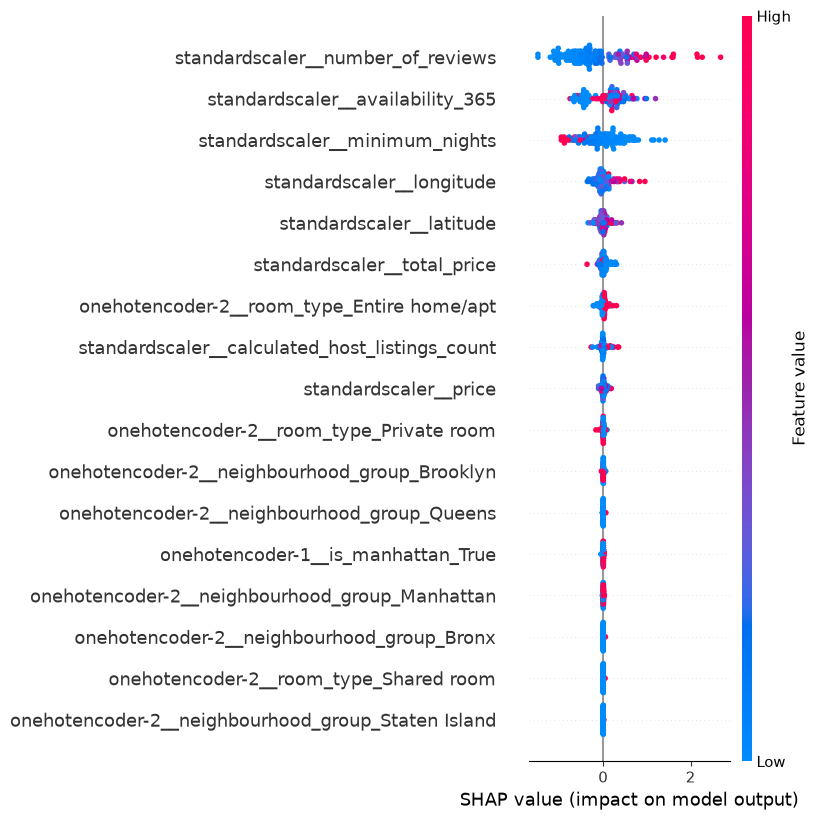

In [47]:
shap.summary_plot(train_shap_values, sample)

### Results 

Using the `SHAP` summary plot, we can see that the most important features for the Random Forest Regressor were `number_of_reviews`, `availability_365` and `minimum_nights`. In addition, `longitude`, `latitude`, and `total_price` also had a noticeable influence, while location-related variables such as `neighbourhood_group`, `is_manhattan` and `room_type` showed smaller contributions. Overall, the top predictors were mainly numerical and continuous features.

<!-- END QUESTION -->

<br><br>

## 12. Final Evaluation on the test set <a id="12"></a>
<hr>

In [48]:
optimized_models_df

,fit_time,score_time,test_score,train_score
decision tree,0.093 (+/- 0.037),0.007 (+/- 0.000),0.467 (+/- 0.034),0.521 (+/- 0.019)
kNN,0.045 (+/- 0.013),0.463 (+/- 0.115),0.424 (+/- 0.036),0.487 (+/- 0.010)
random forest,2.355 (+/- 0.224),0.094 (+/- 0.002),0.546 (+/- 0.035),0.856 (+/- 0.005)


Based on the validation results, the Random Forest model demonstrated the best performance among the tested models. It achieved the highest average validation score ($R^2$ = 0.548) with relatively low variance, indicating stable performance across the validation folds.

Given these results, I will proceed with the Random Forest model and evaluate its performance on the test set using $R^2$ and RMSE.

In [49]:
r2 = rf_model.score(X_test, y_test)
print(f"R\u00B2 score of Random Forest model with optimized hyperparameters: {r2:.4f}")

R² score of Random Forest model with optimized hyperparameters: 0.5667


<br>

The test $R^2$ score of 0.5667 is consistent with, and even slightly better than, the validation scores obtained during cross-validation. This indicates that the model generalizes well to unseen data, which increases confidence in the results. However, since the training score was much higher ($R^2$ = 0.857), there is still some evidence of overfitting to the training data.

Regarding optimization bias, the close validation and test scores suggest that the model's performance was not substantially affected by overfitting during hyperparameter optimization. Since hyperparameter tuning was performed using cross-validation on the training data, while the test set was kept separate for final evaluation, the risk of optimization bias was minimized.


<br>

In [50]:
rmse = float(np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))))
print(f"RMSE score of Random Forest model with optimized hyperparameters: {rmse:.4f}")

RMSE score of Random Forest model with optimized hyperparameters: 1.0742


<br>

The RMSE of 1.0742 means that the Random Forest model’s predictions have a typical error of about 1.0742 reviews per month. Given the scale of the target variable, this indicates a moderate level of prediction error.

<br>

### SHAP Force Plot

Again, to reduce the `SHAP` computation time, I will use a random subset. This speeds up the SHAP value calculation while still allowing meaningful interpretation of the model.

In [51]:
shap.initjs()

X_test_enc = pd.DataFrame( 
    data=preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)

sample = X_test_enc.sample(150, random_state=123)  
test_shap_values = explainer(sample)

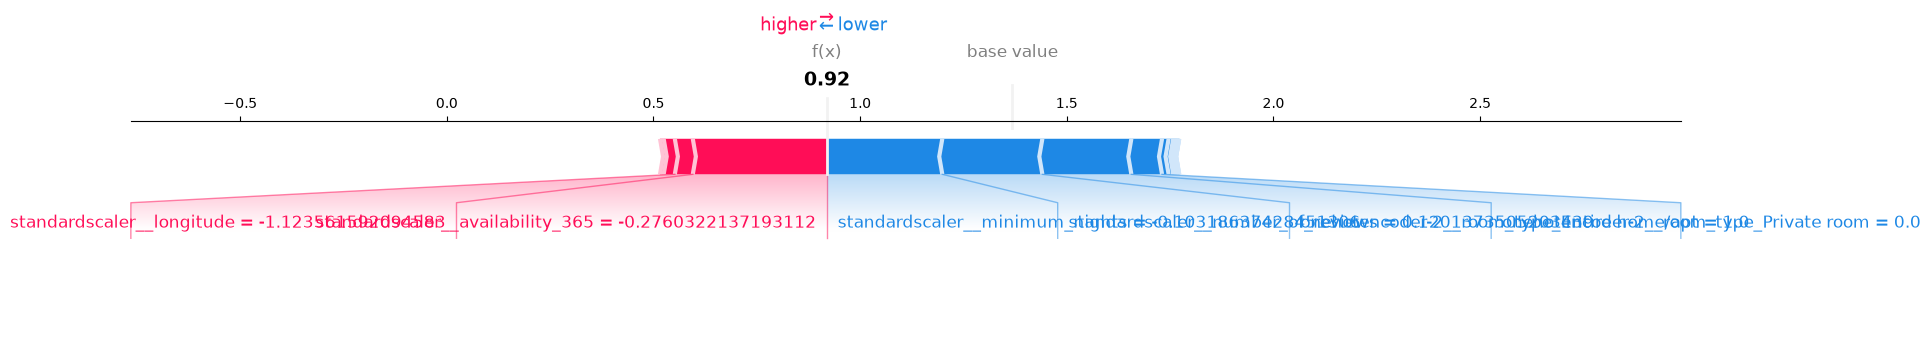

In [52]:
example_idx = 15

shap.force_plot(
    explainer.expected_value,
    test_shap_values[example_idx].values,
    X_test_enc.iloc[example_idx],
    matplotlib=True
)

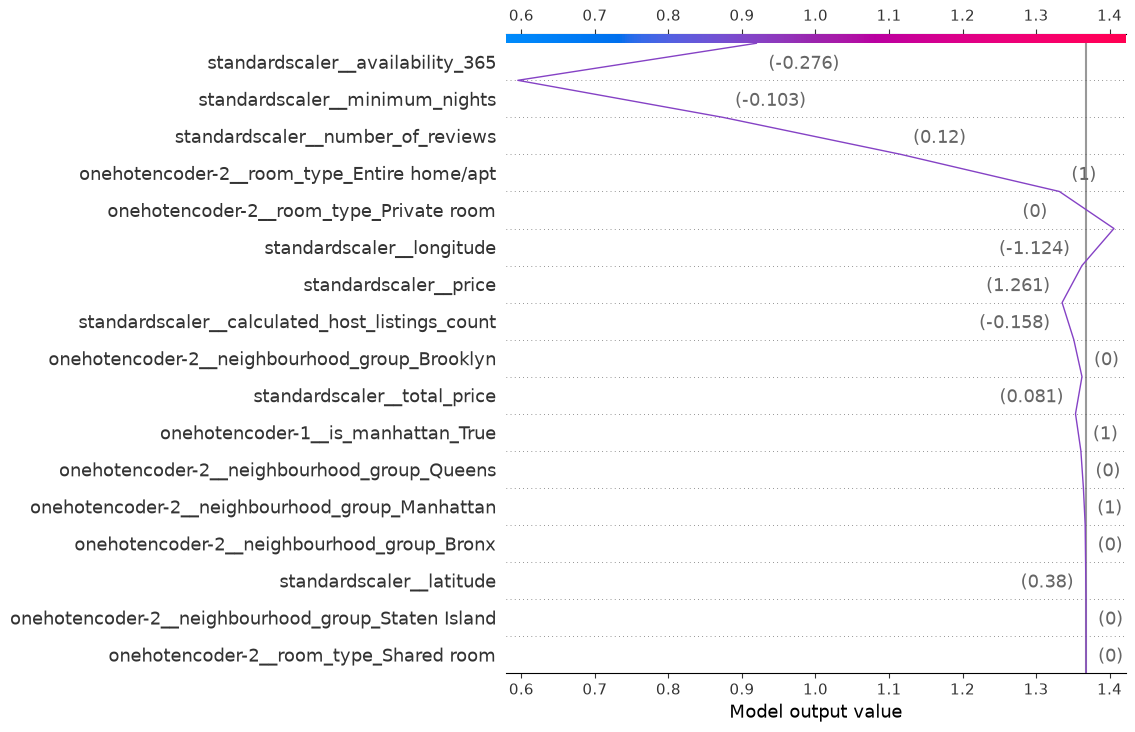

In [53]:
shap.decision_plot(
    explainer.expected_value,
    test_shap_values[example_idx].values,
    X_test_enc.iloc[example_idx]
)

This `SHAP` force plot explains why the model predicted 0.92 for the instance at index 15. The base value, representing the average prediction, was increased primarily by features such as `price` and `latitude`, while `availability_365` and `longitude` had the largest negative contributions. Overall, the positive contributions outweighed the negative ones, resulting in the final prediction of 0.92.

<br><br>

## 13. Summary of results <a id="13"></a>
<hr>

In [54]:
pd.set_option('display.max_colwidth', None)

results_summary = pd.DataFrame({
    "Metric": [
        "Cross-Validation R² (mean ± std)","Cross-Validation R² using RFE (mean ± std)","Training R²  (Model Optimized)",
        "Validation R² (Model Optimized)", "Test R² (Model Optimized)","Test RMSE  (Model Optimized)", "", 
        "Best Hyperparameters (Random Search):", "n_estimators", "min_samples_split", "max_features", "max_depth"
    ],
    "Random Forest Result": [
        "0.526 ± 0.031","0.522 ± 0.034","0.856","0.546", "0.5667","1.0742","","","100", "5","log2","20"
    ]
})

results_summary

,Metric,Random Forest Result
0,Cross-Validation R² (mean ± std),0.526 ± 0.031
1,Cross-Validation R² using RFE (mean ± std),0.522 ± 0.034
2,Training R² (Model Optimized),0.856
3,Validation R² (Model Optimized),0.546
4,Test R² (Model Optimized),0.5667
5,Test RMSE (Model Optimized),1.0742
6,,
7,Best Hyperparameters (Random Search):,
8,n_estimators,100
9,min_samples_split,5


The optimized Random Forest model demonstrated the best performance among the tested algorithms, showing solid generalization with a test $R^2$ of 0.5667 and a reasonable prediction error (RMSE = 1.0742). While some overfitting to the training data was observed, the overall results indicate that the model provides a reasonable approach for predicting `reviews_per_month`.

Potential ways to further improve the model’s performance and interpretability include experimenting with gradient boosting methods such as XGBoost or LightGBM. These methods can capture complex patterns in the data more effectively and may provide improved predictive performance.

Finally, the test $R^2$ of 0.5667 indicates that the model explains approximately 56.67% of the variance in the target variable, `reviews_per_month`.

<br><br>

## 14. Key takeaways <a id="14"></a>
<hr>

* One of the biggest takeaways from the supervised machine learning material was realizing how much we can do to investigate and improve a model without ever touching the test data.

* During this project, it was clear that different algorithms captured different patterns. We saw the Random Forest substantially outperform the linear Ridge model, which showed the value of nonlinear models for this dataset.

* On the other hand, feature selection using `RFECV` did not lead to improvements in model performance, even though adding `total_price` and `is_manhattan` was a useful part of the prior exploration and helped with understanding the data.

* Finally, the evaluation metrics were useful in different parts of the project. For example, comparing training with validation and test performance helped identify overfitting, while $R^2$ and RMSE provided complementary views of predictive performance.

<br><br>

## 15. Limitations and Future Improvements <a id="15"></a>
<hr>

Here is a list of known limitations in this project that could be considered in future iterations of this project or similar experiments:

* **Target variable:** `reviews_per_month` is an indirect measure of listing popularity rather than a direct measure of bookings or demand. A stronger analysis could use additional information, such as booking activity or occupancy data, if available.

* **Feature limitations and temporal information:** The dataset contains a limited set of listing characteristics from a particular point in time. Incorporating additional data across multiple periods could help account for changes in demand, seasonality, and market conditions.

* **Modeling:** The Random Forest performed best among the models tested, but other ensemble methods, such as Gradient Boosting, XGBoost, or LightGBM, could also be explored to determine whether they can improve predictive performance.

* **Feature selection:** RFECV did not improve the model in this analysis. Future work could further investigate alternative feature-selection and feature-engineering approaches.